### Apply on data

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import jax
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import gcmi_model_nd_cd
from frites.workflow import WfStats
from hoi.core import get_mi
from mne.filter import filter_data
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from session import session_info
from tqdm import tqdm

/home/INT/brovelli.a/code/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### Functions

In [4]:
def trial_to_string(trial_no, n_max):
    trial_no = str(trial_no)
    n = len(trial_no)
    return (n_max - n) * "0" + trial_no

In [5]:
def shuffle_along_axis(a, axis):
    """Shuffle data along specified axis."""
    idx = np.random.rand(*a.shape).argsort(axis=axis)
    return np.take_along_axis(a, idx, axis=axis)


def create_generalized_surrogates(X, n_boot=10000):
    """Create semi-generalized surrogate."""
    T, R, N = X.shape  # Extract dimensions

    # Trials onsets
    t_match_on = (data.attrs["t_match_on"] - data.attrs["t_cue_on"]) / data.fsample
    t_match_on = np.round(t_match_on, 1)

    X = X.values

    # Sample trials
    count = 0
    trials_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(T),
            size=2,
            replace=False,
        )
        trials_surr += [out]
        count = count + 1
    trials_surr = np.stack(trials_surr)

    # Sample channels
    count = 0
    channels_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(R),
            size=2,
            replace=False,
        )
        channels_surr += [out]
        count = count + 1
    channels_surr = np.stack(channels_surr)

    data_surr = []
    for c_i, c_j, trial_i, trial_j in np.concatenate(
        (channels_surr, trials_surr), axis=1
    ):
        x = X[trial_i, c_i]
        y = X[trial_j, c_j]  # [..., ::-1]
        data_surr += [np.stack((x, y))]

    # Get shortest onset time for each pair of sampled trials
    onsets = []
    for t1, t2 in trials_surr:
        onsets += [min(t_match_on[t1], t_match_on[t2])]
    onsets = np.stack(onsets)

    return np.stack(data_surr), onsets

#### Load data

In [6]:
# session = sessions[index]
session = "090615"
data_dir = "/home/INT/brovelli.a/envau/work/brainets/data/db_lfp/lfp_graylab/betty/"

In [7]:
root = f"{data_dir}/{session}/session01/"

In [8]:
trial_info = {}
scipy.io.loadmat(
    os.path.join(root, "trial_info.mat"), simplify_cells=True, mdict=trial_info
)
trial_info = trial_info["trial_info"]

In [9]:
recording_info = {}
scipy.io.loadmat(
    os.path.join(root, "recording_info.mat"), simplify_cells=True, mdict=recording_info
)
recording_info = recording_info["recording_info"]

In [10]:
task_trials = np.where(
    trial_info["behavioral_response"]
    * trial_info["stable_trials"]
    * trial_info["good_trials"]
)[0]

In [11]:
stim = []

for trial in task_trials:

    if trial_info["rule"][trial] == 1:
        stim.append(trial_info["match_image"][trial])
    else:
        stim.append(trial_info["match_location"][trial])

In [12]:
time_array = np.arange(-0.4, 1.7, 1 / recording_info["lfp_sampleingrate"])

In [13]:
n_trials, n_channels, n_times = (
    len(task_trials),
    recording_info["channel_count"],
    len(time_array),
)

In [14]:
data = np.empty((n_trials, n_channels, n_times))  # LFP data

# For each selected trial
i = 0
for trial in tqdm(task_trials):

    lfp_data = scipy.io.loadmat(
        os.path.join(root, f"betty{session}01.{trial_to_string(trial + 1, 4)}.mat")
    )["lfp_data"]

    # Beggining and ending time index for this t0
    indb = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.min()
    )
    inde = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.max()
    )
    # LFP data, dimension NtrialsxNchannelsxTime
    data[i, ...] = lfp_data[:, indb : inde + 1]

    i = i + 1

100%|██████████| 993/993 [00:08<00:00, 114.64it/s]


#### Convert to xarray

In [15]:
data = xr.DataArray(
    data,
    dims=("trials", "roi", "times"),
    coords=(
        # trial_info["match_image"][task_trials],
        stim,
        recording_info["area"],
        time_array,
    ),
    attrs={
        "t_match_on": trial_info["match_on"],
        "t_cue_on": trial_info["sample_on"],
        "fsample": recording_info["lfp_sampleingrate"],
    },
)

(np.float64(-0.5),
 np.float64(1.7),
 np.float64(-4.561347220428129),
 np.float64(18.97876915494901))

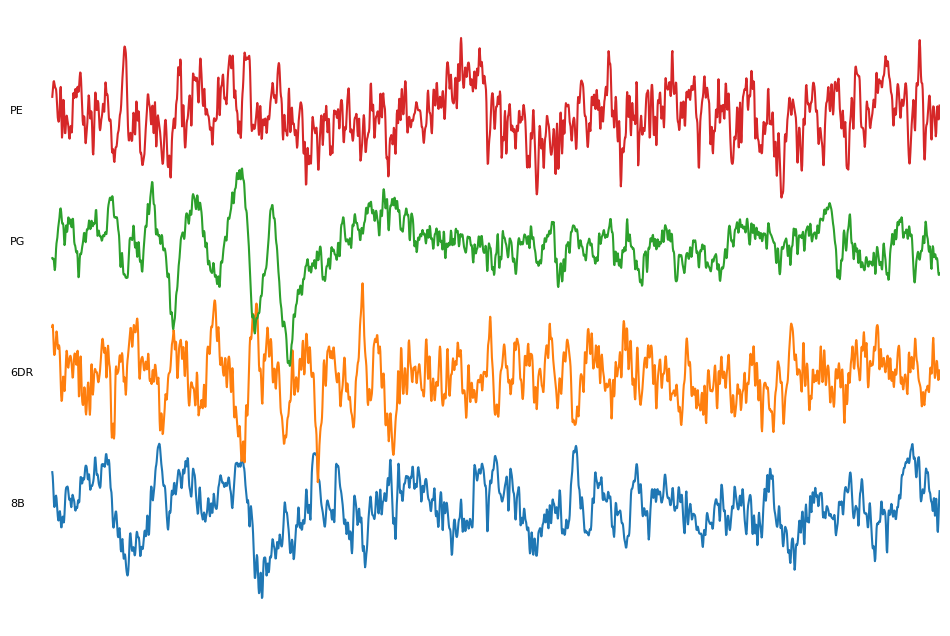

In [16]:
plt.figure(figsize=(12, 8))
zdata = (data - data.mean("times")) / data.std("times")


for i in range(data.sizes["roi"]):

    plt.plot(data.times, zdata[0, i] + (i * 5))
    plt.text(-0.5, (i * 5), zdata.roi.values[i])

plt.xlim(-0.5, 1.7)
plt.axis("off")

#### Stimulus related coherence (SCR)

In [17]:
# Select a subset of trials
# data = data[:500]# --- IGNORE ---

In [18]:
# Compute complex Morlet wavelet coefficients across frequencies.
freqs = np.linspace(5., 35, 31)

W = tfr_array_multitaper(
    data,
    recording_info["lfp_sampleingrate"],
    freqs,
    n_cycles=freqs / 2,
    decim=20,
    time_bandwidth=5,
    output="complex",
    verbose=True,
)

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   11.5s finished


In [19]:
# Select pairs of channels (upper triangle of the connectivity matrix)
x_s, x_t = np.triu_indices(data.sizes["roi"], 1)

# Compute complex-valued variable z for each pair of channels
# z = W[:, x_s] * np.conj(W[:, x_t])
z = (W[:, x_s] * np.conj(W[:, x_t])).mean(2)

# Compute amplitude and phase difference
A = np.abs(z)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# Transpose A and dphi to have the first dim to the last
A = A.transpose(1, 2, 3, 0)
dphi = dphi.transpose(1, 2, 3, 0)

# Create multivariate variable by stacking A and dphi
mv = np.stack((A, dphi))

In [20]:
I_S_R1 = gcmi_model_nd_cd(A[None], np.asarray(data.trials.values), gcrn=True)[0]

In [21]:
I_S_R2 = gcmi_model_nd_cd(dphi[None], np.asarray(data.trials.values), gcrn=True)[0]

In [22]:
I_S_R1_R2 = gcmi_model_nd_cd(mv, np.asarray(data.trials.values), mvaxis=0, gcrn=True)

In [23]:
from joblib import Parallel, delayed


def compute_shuffle(mv):

    # compute MI
    return gcmi_model_nd_cd(
        mv, np.random.permutation(data.trials.values), mvaxis=0, gcrn=True
    )

In [24]:
# run in parallel
I_S_R1_R2_shuffle = Parallel(n_jobs=-1)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(1000))
)

100%|██████████| 1000/1000 [01:24<00:00, 11.78it/s]


In [25]:
x = [np.asarray(I_S_R1_R2[i][None]) for i in range(len(x_s))]
y = [np.stack(I_S_R1_R2_shuffle)[:, i][:, None] for i in range(len(x_s))]

In [26]:
wf = WfStats()

p, t = wf.fit(
    x,
    y,
    inference="ffx",
    mcp="cluster",
)

p = p.squeeze()

p.min()

Definition of a non-parametric statistical workflow
    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.00876313540958637; tail=1)


np.float64(0.001)

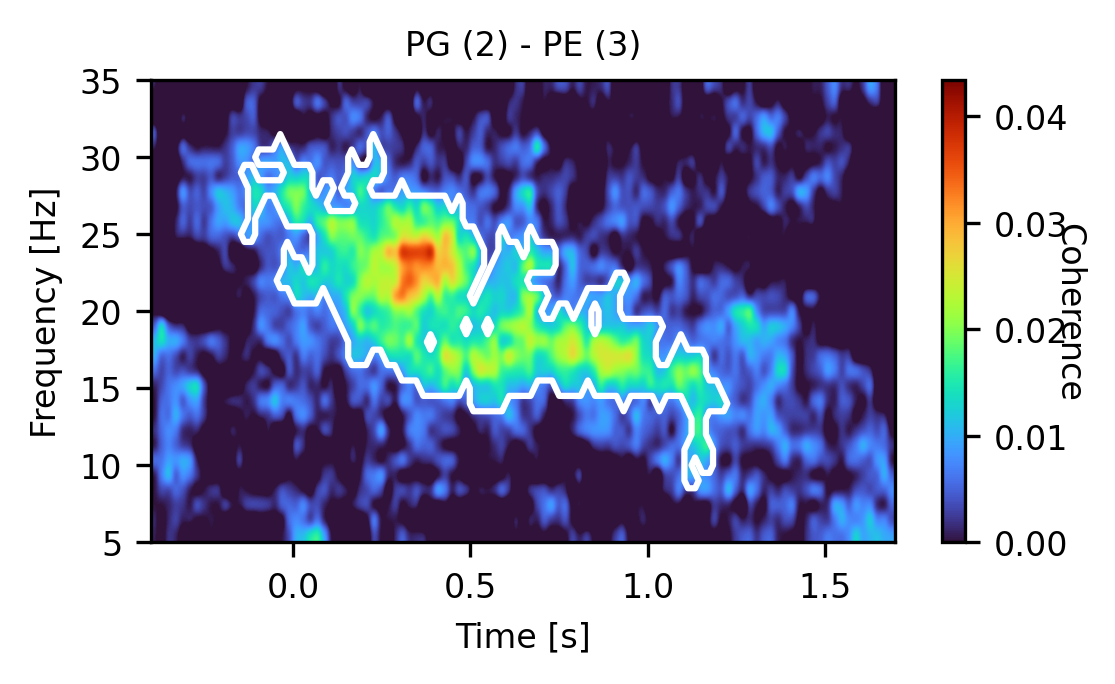

In [27]:
fig = plt.figure(num=1, clear=True, figsize=(4, 2), dpi=300)

pos = 0

for i, j in zip(x_s, x_t):

    fig = plt.figure(num=1, clear=True)

    plt.imshow(
        I_S_R1_R2[pos],
        aspect="auto",
        origin="lower",
        cmap="turbo",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
        vmin=0,
        interpolation="gaussian",
        vmax=I_S_R1_R2[pos].max(),
    )
    cbar = plt.colorbar()

    plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

    cbar.set_label("Coherence", rotation=270)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")

    plt.contour(
        (p[..., pos] <= 0.05),
        levels=[0.5],
        colors="w",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
    )

    pos = pos + 1

In [28]:
red = np.minimum(I_S_R1, I_S_R2)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)

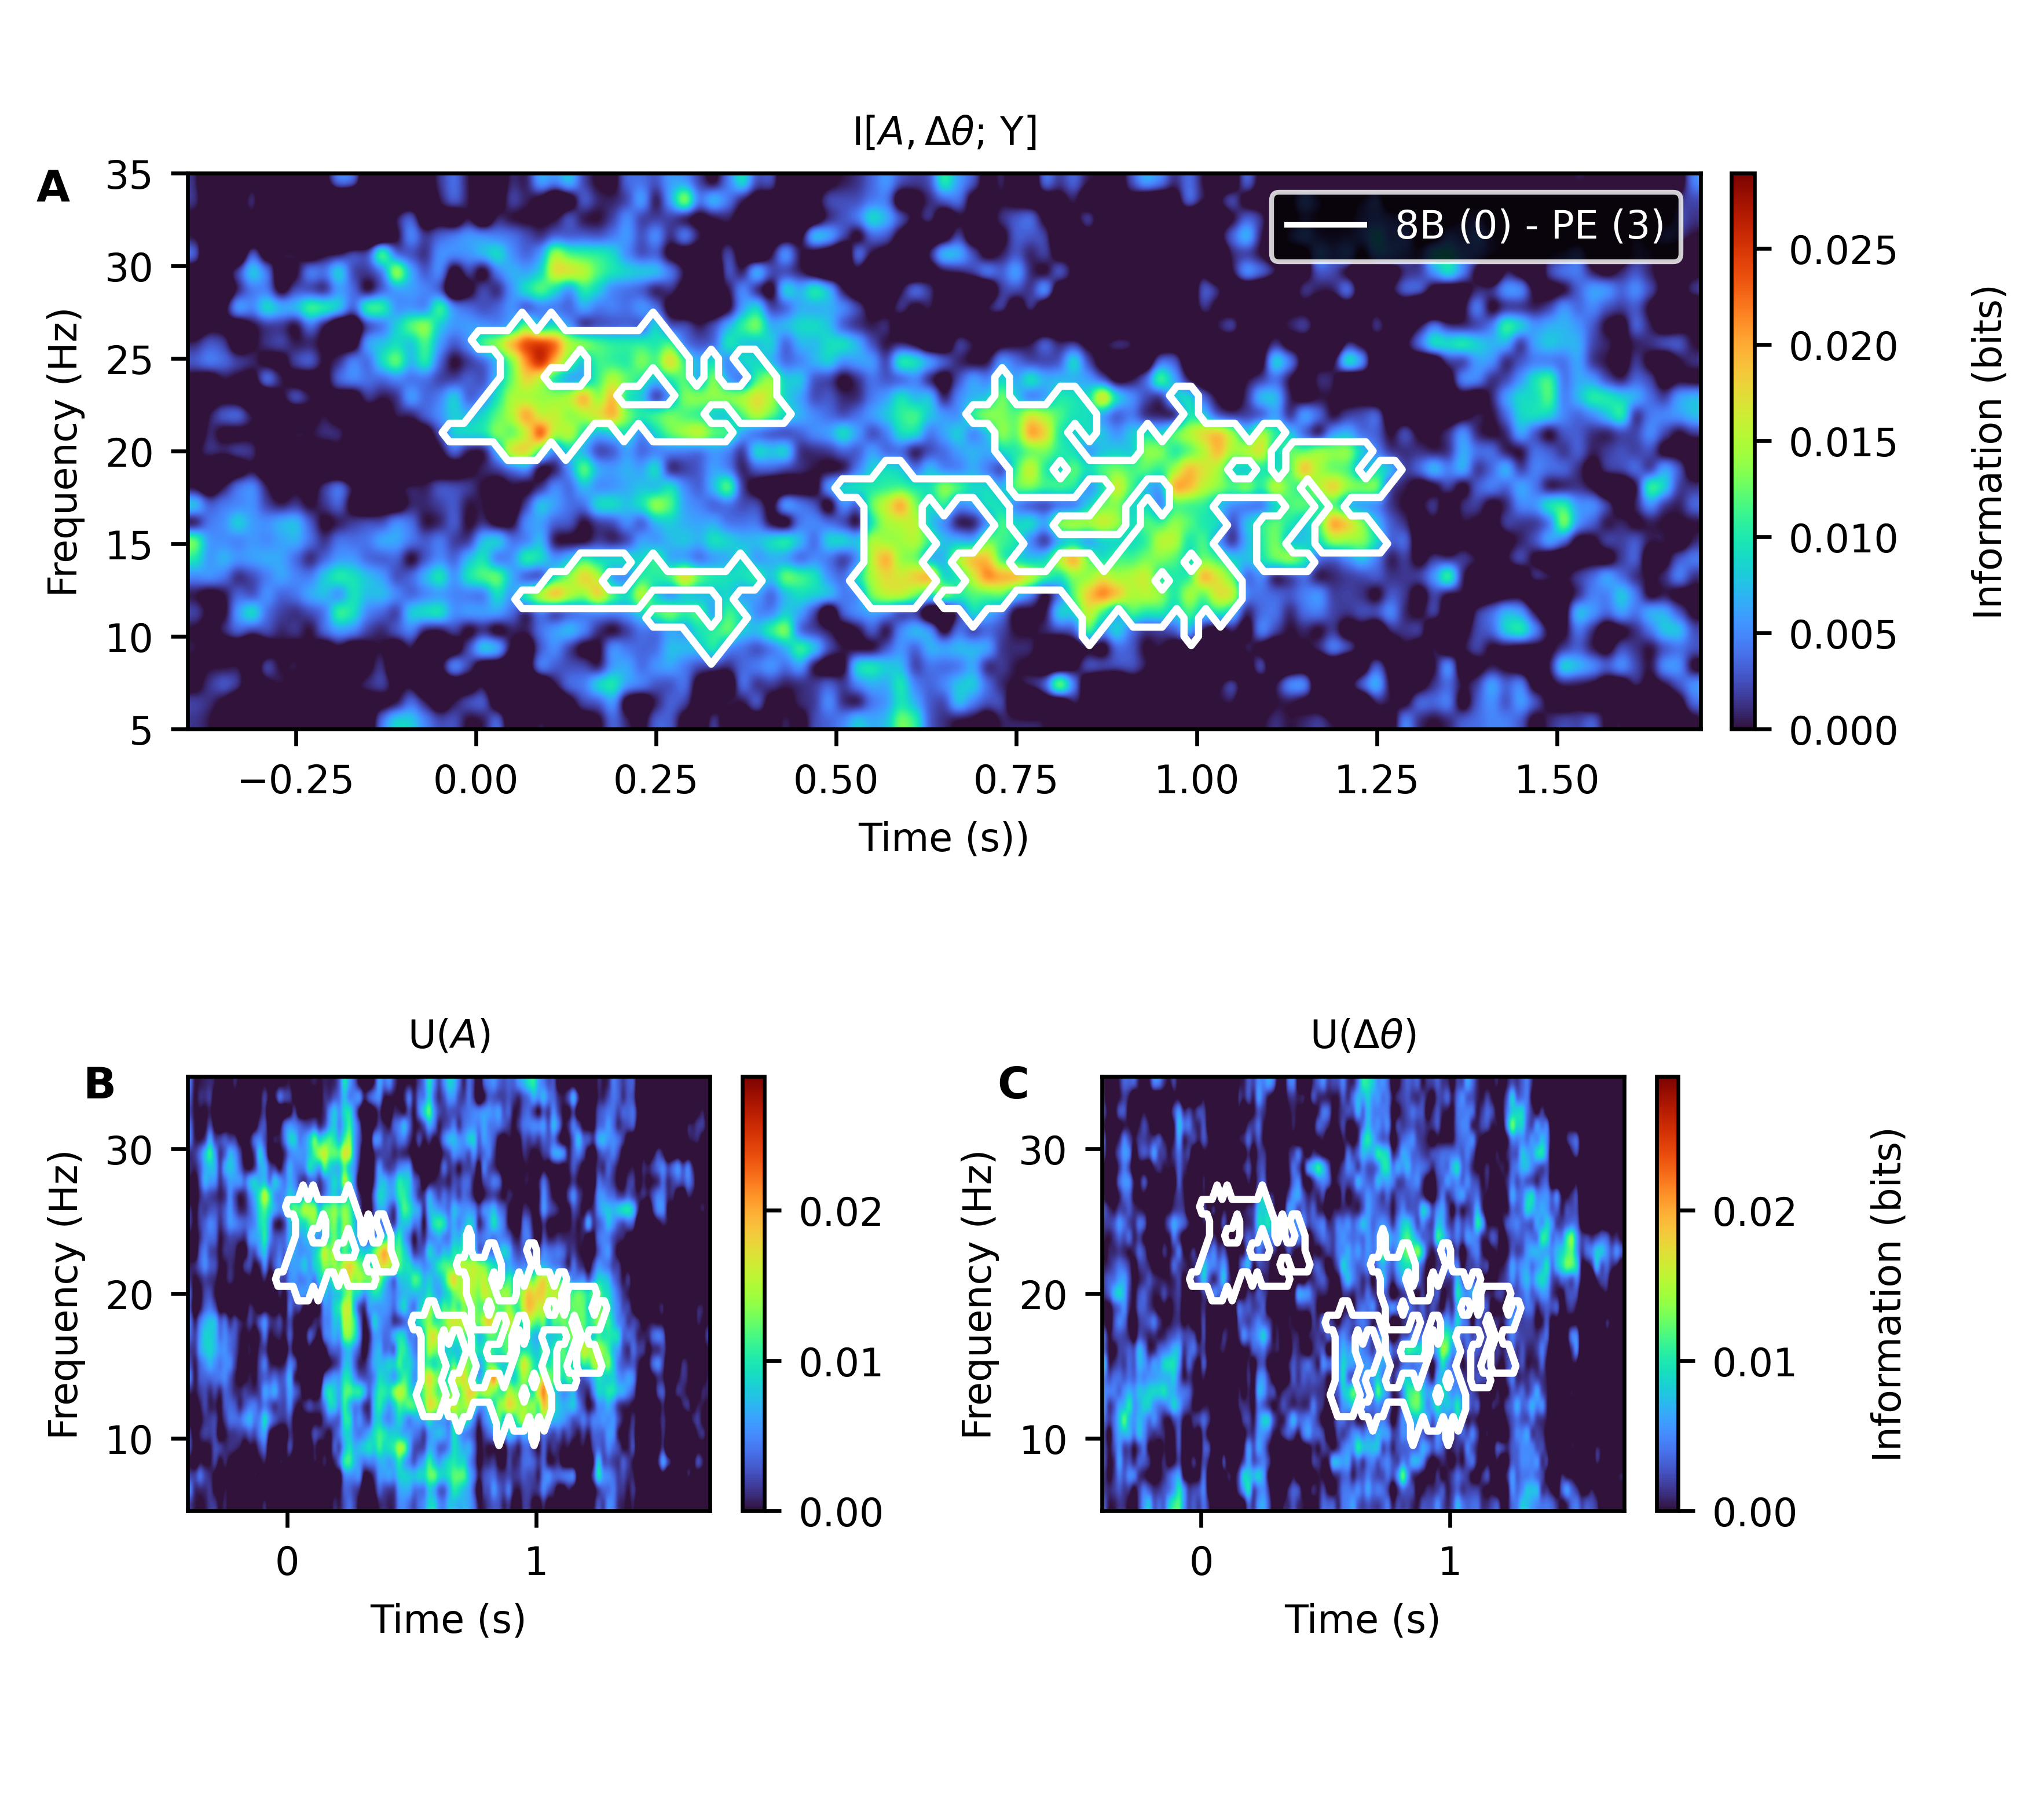

In [ ]:
import plot
from matplotlib.lines import Line2D
from PIL import Image

pos = 2

t_min, t_max = float(data.times.min()), float(data.times.max())

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.90,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.97, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2[pos],
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label("Information (bits)", rotation=90, labelpad=15)

plt.contour(
    (p[..., pos].squeeze() <= 0.5).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(r"I[$A, \Delta\theta$; Y]")


plt.xlabel("Time (s))")
plt.ylabel("Frequency (Hz)")

# Legend explaining the white contour line on Panel A
ax1.legend(
    handles=[Line2D([0], [0], color="w", lw=1.2, label=f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")],
    loc="upper right",
    frameon=True,
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    fontsize=SMALL_SIZE,
)

plt.sca(ax2)
plt.imshow(
    (I_S_R1[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p[..., pos].squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)


plt.title(r"U($A$)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.sca(ax3)

plt.imshow(
    (I_S_R2[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=I_S_R1_R2.max() / 1.5,
)
cbar = plt.colorbar()

plt.title(r"U($\Delta\theta$)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
cbar.set_label("Information (bits)", rotation=90, labelpad=15)
plt.contour(
    (p[..., pos].squeeze() <= 0.05).astype(float),
    levels=[0.5],
    colors="w",
    extent=[t_min, t_max, freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.1] + [-0.2] * 2,
    ypos=[0.99] * 3,
)

plt.savefig("../figures/Figure6.pdf")

Figure 6: Phase- and amplitude encoding in fronto-parietal recordings during working memory. A
Stimulus-related coherence given by the total mutual-information between phase- and amplitude about
the stimulus (Eq. 3) for a fronto-parietal channel pair (8B - PE). B,C Unique information about the stimulus
contained in the joint amplitude and phase-difference components of the signal. Areas delimited by the
white line correspond to significant effects obtained via shuffling surrogates (n = 1000; p < 0.05; corrected
using cluster statistics).

In [30]:
i, j = 2, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh1 = np.abs(Sxy) ** 2 / (Sxx * Syy)

i, j = 0, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh2 = np.abs(Sxy) ** 2 / (Sxx * Syy)

In [31]:
z = (W[:, 0] * np.conj(W[:, 1])).mean(1)

dphi1 = np.abs(z)[None]  # np.stack((z.real, z.imag))
# dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)


z = (W[:, 2] * np.conj(W[:, 3])).mean(1)
dphi2 = np.abs(z)[None]  # np.stack((z.real, z.imag))

mv = np.concatenate((dphi1, dphi2))

# labels = np.tile(np.expand_dims(data.trials.values, (1, 2)), (W.shape[3], W.shape[4]))


In [32]:
# Transpose A and dphi to have the first dim to the last
dphi1 = dphi1.transpose(0, 2, 3, 1)
dphi2 = dphi2.transpose(0, 2, 3, 1)
mv = mv.transpose(0, 2, 3, 1)

In [33]:

I_S_R1_hoi = gcmi_model_nd_cd(
    dphi1, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

I_S_R2_hoi = gcmi_model_nd_cd(
    dphi2, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

I_S_R1_R2_hoi = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, gcrn=True
)

In [34]:
# run in parallel
I_S_R1_R2_hoi_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(200))
)

100%|██████████| 200/200 [00:19<00:00, 10.33it/s]


In [35]:
p_hoi, t = wf.fit(
    [np.asarray(I_S_R1_R2_hoi[None])],
    [np.stack(I_S_R1_R2_hoi_shuffle)[:, None]],
    inference="ffx",
    mcp="cluster",
)

p_hoi = p_hoi.squeeze()

p_hoi.min()

    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.008981525336742362; tail=1)


np.float64(0.005)

In [36]:
red = np.minimum(I_S_R1_hoi, I_S_R2_hoi)
syn = I_S_R1_R2_hoi - np.maximum(I_S_R2_hoi, I_S_R1_hoi)

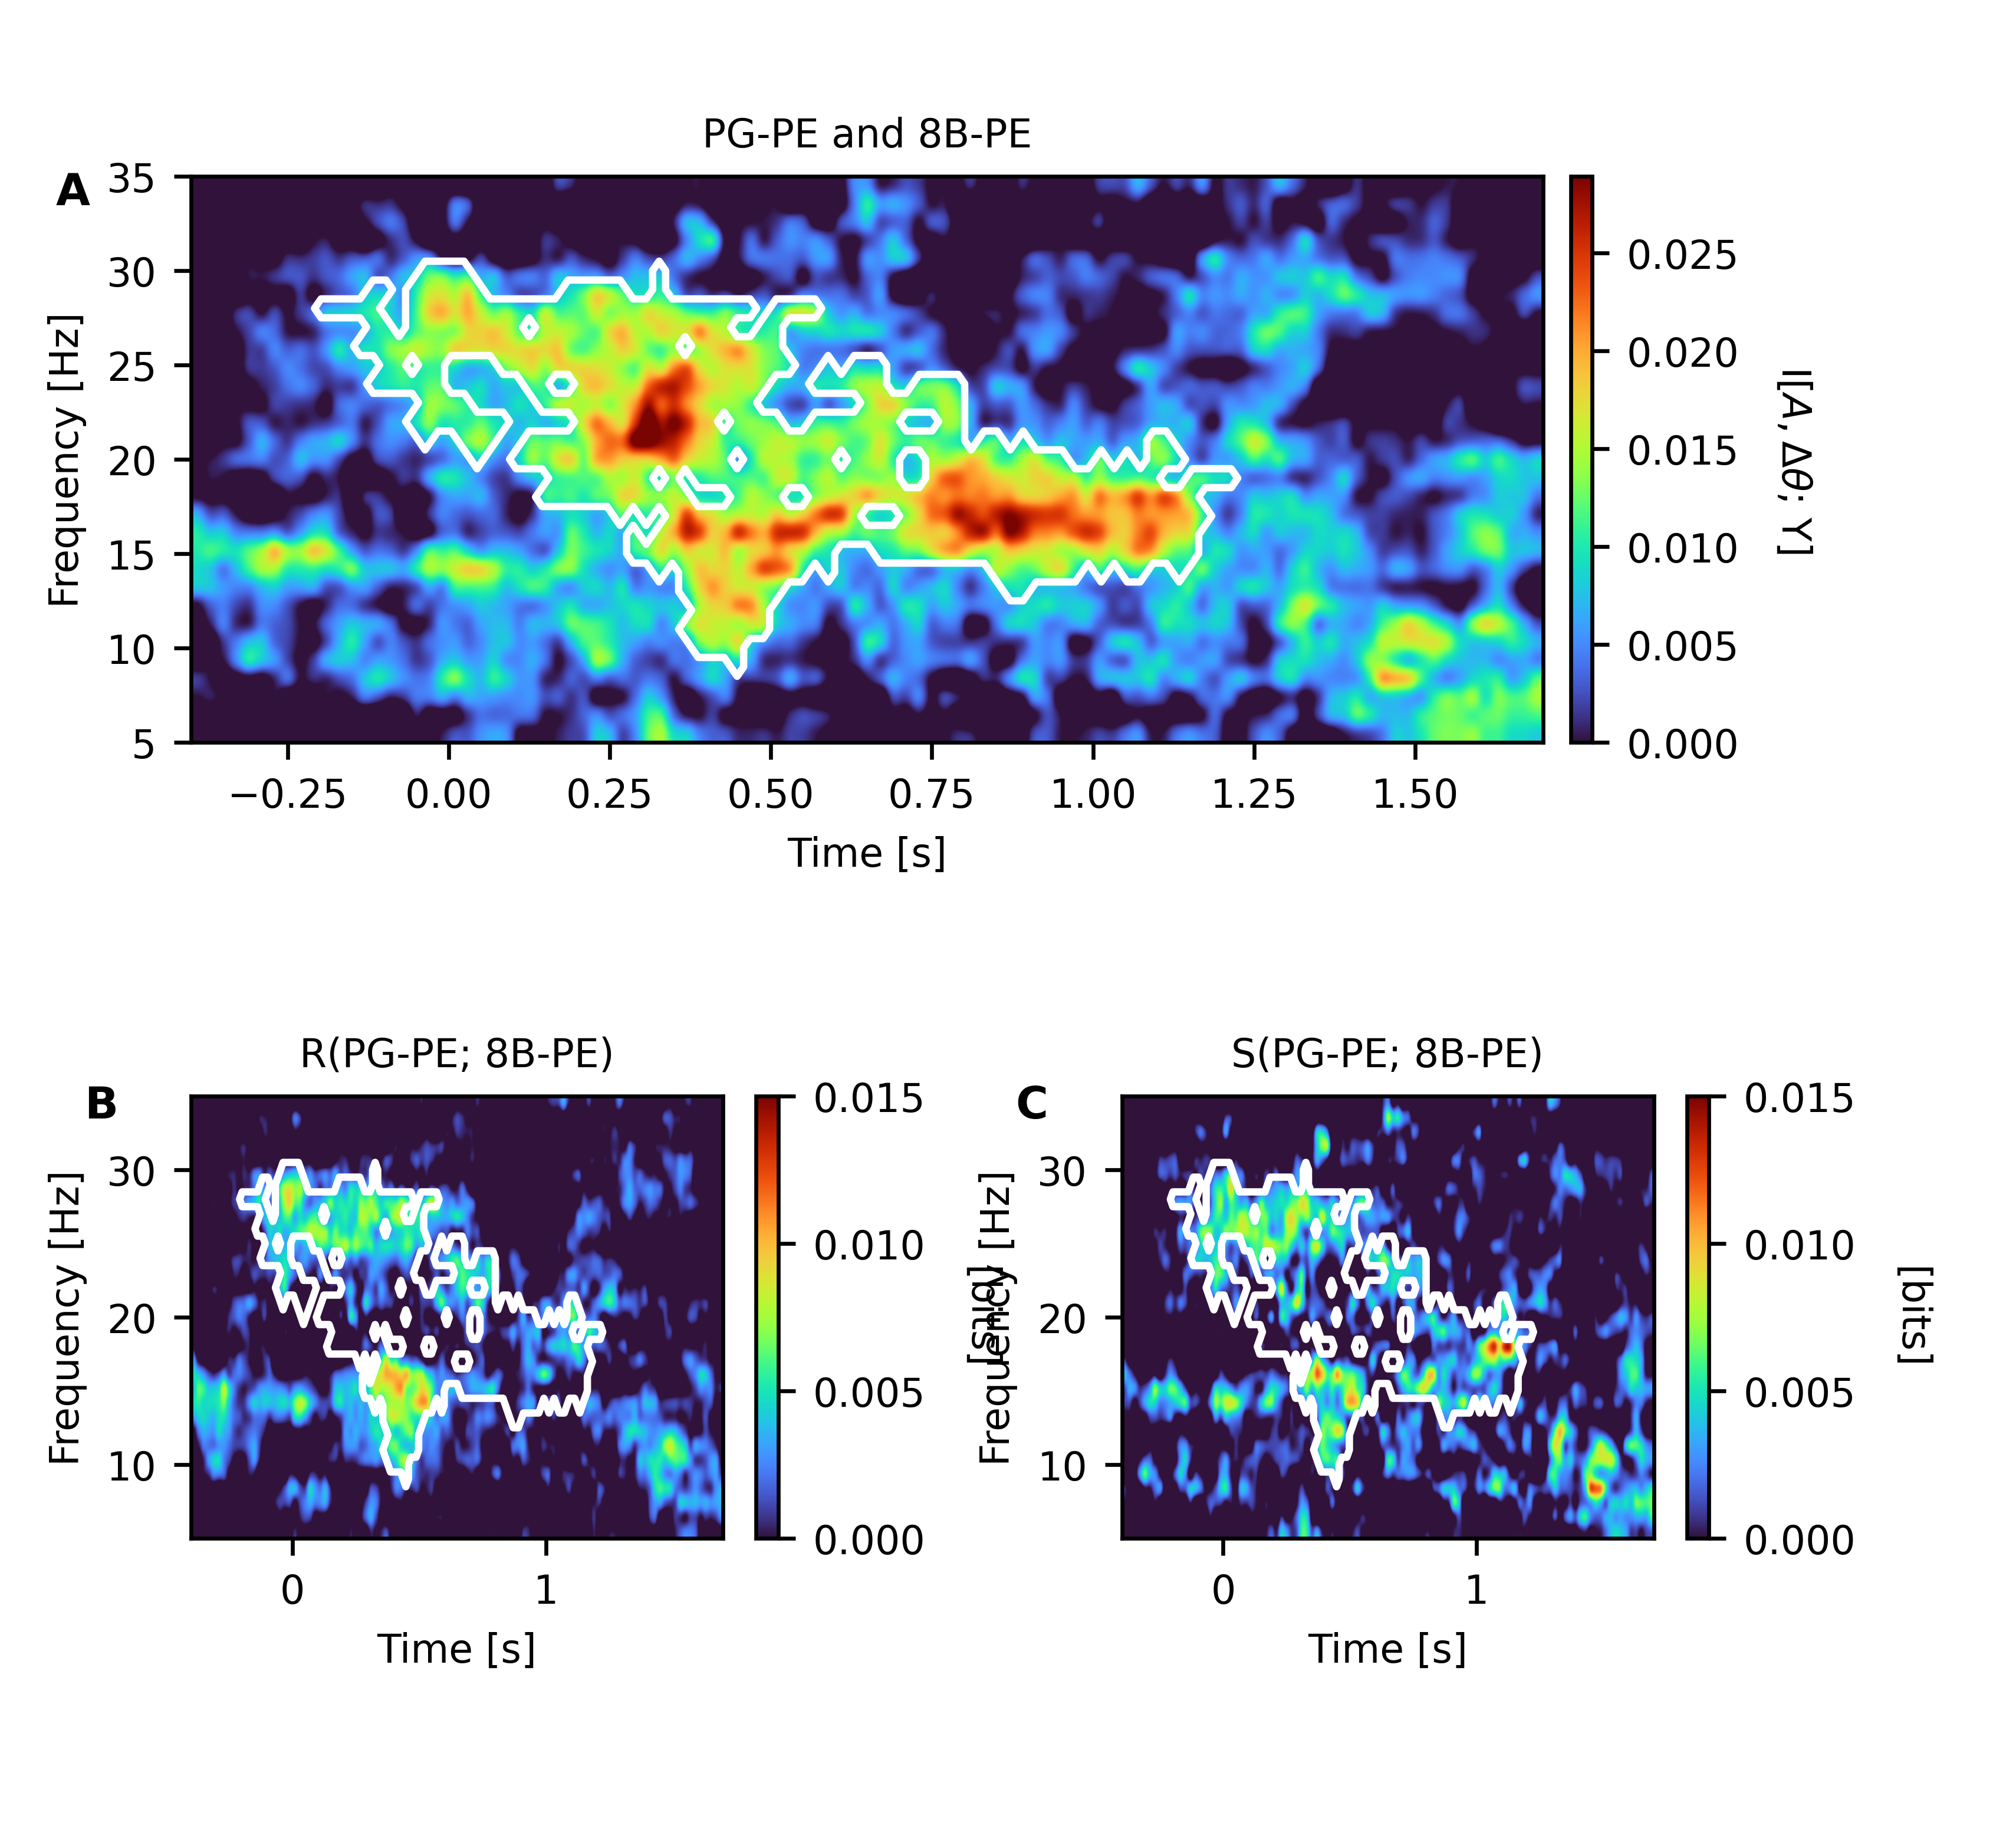

In [37]:
import plot
from PIL import Image

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.8,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.95, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2_hoi,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label(r"I[$A, \Delta\theta$; Y]", rotation=270, labelpad=15)

plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(f"PG-PE and 8B-PE")

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

plt.sca(ax2)
plt.imshow(
    red,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=0.015,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
)


plt.title(r"R(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
cbar.set_label("[bits]", rotation=270, labelpad=15)

plt.sca(ax3)

plt.imshow(
    syn,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=0.015,
)
cbar = plt.colorbar()

plt.title(r"S(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("[bits]", rotation=270, labelpad=15)
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.1] + [-0.2] * 2,
    ypos=[0.95] * 3,
)

plt.savefig("../figures/Figure7.pdf")

Figure 7: High-order phase- and amplitude encoding during working memory. (A) Stimulus-related
coherence given by the total mutual-information between phase- and amplitude edges for parietal-parietal
channel pair PG-PE and fronto-parietal channel pair 8B-PE about the stimulus (Eq. 3). The amplitude-phase
edge for each channel pair is given by Eqs. 10. (B) High-order redundant information about the stimulus
contained in the joint amplitude and phase-difference components of the signal. Areas delimited by the
white line correspond to significant effects obtained via shuffling surrogates (n = 1000; p < 0.05; corrected
using cluster statistics). (C) The same as (B) but showing the high-order synergistic information.